# Exercise 1
**Veikka Immonen**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.gaussian_process.kernels import Matern

from joblib import Parallel, delayed

## Task 1

### Define the grid.

In [12]:
n = 101
T1 = np.arange(n) / (n - 1)                 # 1D
T2 = np.asarray(list(product(T1, T1)))      # 2D

### Visualize:

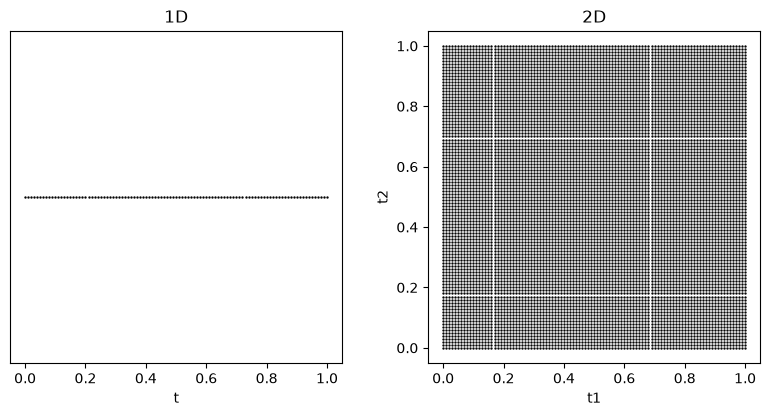

In [13]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.scatter(T1, np.zeros_like(T1), c='k', s=0.5)
ax1.set_title("1D")
ax1.set_yticks([], [])
ax1.set_xlabel("t")

ax2.scatter(*T2.T, c='k', s=0.5)
ax2.set_title("2D")
ax2.set_xlabel("t1")
ax2.set_ylabel("t2")

ax1.set_ylim(-.55, .55)
ax1.set_aspect("equal")
ax2.set_aspect("equal")

plt.tight_layout()
plt.savefig("grids.pdf")

### Build the covariance matrix using Matérn kernel.

In [14]:
length_scale = 0.1
nu = 1.5

kernel = Matern(length_scale=length_scale, nu=nu)
K1 = kernel(T1[:, None])
K2 = kernel(T2)

### Compute Cholesky decomposition

In [15]:
L1 = np.linalg.cholesky(K1)
L2 = np.linalg.cholesky(K2)

### Sample and visualize

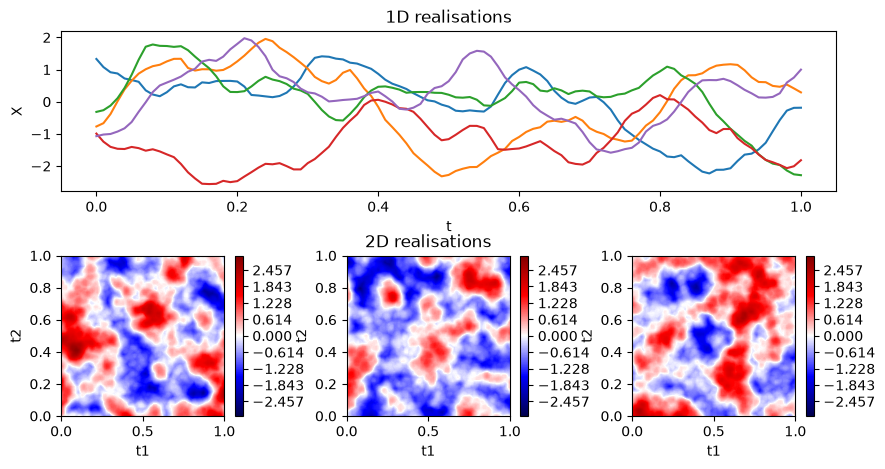

In [16]:
np.random.seed(24)

W1 = np.random.randn(n, 5)
W2 = np.random.randn(n**2, 3)

X1 = L1 @ W1
X2 = L2 @ W2

fig = plt.figure(figsize=(10, 5))

gs = fig.add_gridspec(2, 3, height_ratios=[1, 1],
                      hspace=0.4, wspace=0.4)

ax_top = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[1, 2])

ax_top.plot(T1, X1)
ax_top.set_title("1D realisations")
ax_top.set_xlabel("t")
ax_top.set_ylabel("X")

TT = T2.reshape((n, n, 2))
XX = X2.reshape((n, n, 3))
levels = np.linspace(-3, 3, 255)
for i, ax in enumerate((ax1, ax2, ax3)):
    c = ax.contourf(TT[..., 0], TT[..., 1], XX[..., i], levels, cmap="seismic")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("t1")
    ax.set_ylabel("t2")

ax2.set_title("2D realisations")

plt.savefig("realisations.pdf", pad_inches=0)

## Task 2

### Wrapper for Gaussion process regression.

In [3]:
def gpr(xs, x, y, kernel, sigma=0.0):
    K = kernel(x)
    Ks = kernel(x, xs)
    L = np.linalg.cholesky(K + sigma**2 * np.eye(len(K)))
    L_inv = np.linalg.inv(L)
    a = L_inv.T @ (L_inv @ y)
    ys_mean = Ks.T @ a
    v = L_inv @ Ks
    ys_cov = kernel(xs) - v.T @ v
    return ys_mean, ys_cov

### Visualize

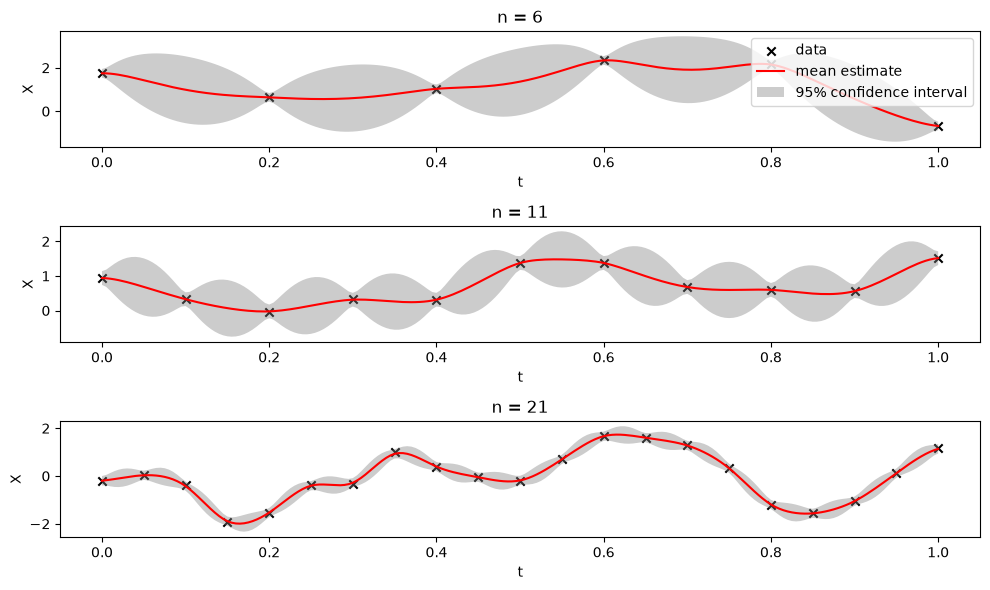

In [41]:
np.random.seed(0)

sigma = 0.1
_, axes = plt.subplots(3, 1, figsize=(10, 6))
N = [6, 11, 21]
ns = 201
Ts = np.arange(ns) / (ns - 1)

length_scale = 0.1
nu = 1.5
kernel = Matern(length_scale=length_scale, nu=nu)

for n, ax in zip(N, axes):
    T = np.arange(n) / (n - 1)
    K = kernel(T[:, None])
    L = np.linalg.cholesky(K)
    W = np.random.randn(n)
    X = L @ W

    Xs_mu, Xs_cov = gpr(Ts[:, None], T[:, None], X, kernel, sigma)
    Xs_std = np.diag(Xs_cov)
    Xs_std = np.where(Xs_std < 0, 0, Xs_std)
    Xs_std = np.sqrt(Xs_std)

    ax.scatter(T, X, marker='x', c='k', label="data")
    ax.plot(Ts, Xs_mu, 'r', label="mean estimate")
    ax.fill_between(Ts, Xs_mu + 2*Xs_std, Xs_mu - 2*Xs_std,
                    color="gray", alpha=0.4, edgecolor=None,
                    label="95% confidence interval")
    ax.set_xlabel("t")
    ax.set_ylabel("X")

    ax.set_title(f"{n = }")
    if n == 6:
        ax.legend()


plt.tight_layout()
plt.savefig("gpr_1d.pdf")


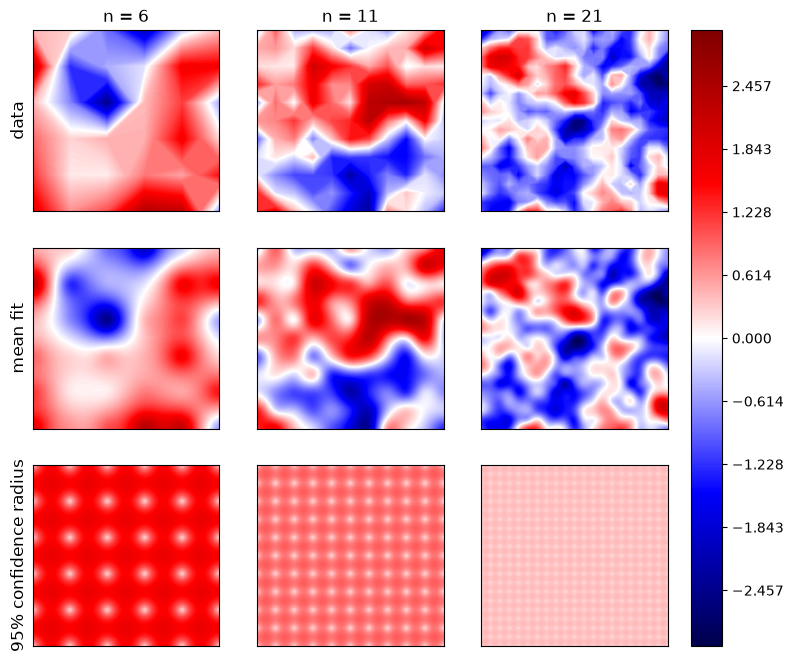

In [49]:
np.random.seed(0)

sigma = 0.1
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
N = [6, 11, 21]
ns = 101
Ts = np.arange(ns) / (ns - 1)
Ts = np.asarray(list(product(Ts, Ts)))
TTs = Ts.reshape((ns, ns, 2))

length_scale = 0.1
nu = 1.5
kernel = Matern(length_scale=length_scale, nu=nu)

levels = np.linspace(-3, 3, 255)

for n, (ax1, ax2, ax3) in zip(N, zip(*axes)):
    T = np.arange(n) / (n - 1)
    T = np.asarray(list(product(T, T)))
    K = kernel(T)
    L = np.linalg.cholesky(K)
    W = np.random.randn(n**2)
    X = L @ W

    Xs_mu, Xs_cov = gpr(Ts, T, X, kernel, sigma)
    Xs_std = np.diag(Xs_cov)
    Xs_std = np.where(Xs_std < 0, 0, Xs_std)
    Xs_std = np.sqrt(Xs_std)

    TT = T.reshape((n, n, 2))

    XX = X.reshape((n, n))
    XXs_mu = Xs_mu.reshape((ns, ns))
    XXs_std = Xs_std.reshape((ns, ns))

    ax1.contourf(*TT.T, XX, levels, cmap="seismic")
    ax2.contourf(*Ts.reshape((ns, ns, 2)).T, Xs_mu.reshape((ns, ns)), levels, cmap="seismic")
    c = ax3.contourf(*Ts.reshape((ns, ns, 2)).T, 2*Xs_std.reshape((ns, ns)), levels, cmap="seismic")
    ax1.set_title(f"{n = }")
    if n == 6:
        ax1.set_ylabel("data", fontsize=12)
        ax2.set_ylabel("mean fit", fontsize=12)
        ax3.set_ylabel("95% confidence radius", fontsize=12)
    for ax in (ax1, ax2, ax3):
        ax.set_xticks([], [])
        ax.set_yticks([], [])

cbar = fig.colorbar(c, ax=axes.ravel(), location="right", shrink=1.0, pad=0.03)

plt.savefig("gpr_2d.pdf", pad_inches=0)

### Sampler functions and wrappers to benchmark them:
* MH
* pCN

Initial state is set to the least-squares linear fit.

In [2]:
def fit_linear(X, y):
    X = np.pad(X, ((0, 0), (0, 1)), constant_values=1)
    b = np.linalg.solve(X.T @ X, X.T @ y)
    return b


def mh_chain_norm(L_covar, init, log_posterior, chain_length, beta):
    """
    Simple Gaussian random walk MCMC sampler using Metropolis-Hastings algorithm.
    """

    d = len(init)
    chain = []
    acc_probs = []

    old = init
    lp_old = log_posterior(old)

    for _ in range(chain_length):
        w = np.random.randn(d)
        new = old + beta * L_covar @ w
        lp_new = log_posterior(new)
        ratio = np.exp(lp_new - lp_old)
        a = min(ratio, 1)
        u = np.random.rand()
        acc_probs.append(a)
        if u <= a:
            old = new
            lp_old = lp_new
        chain.append(old)

    return np.asarray(chain), np.asarray(acc_probs)


def pcn_chain_norm(L_covar, init, log_likelihood, chain_length, beta):
    """
    Simple Gaussian random walk MCMC sampler using preconditioned Crank-Nicolson algorithm.
    """

    d = len(init)
    chain = []
    acc_probs = []

    old = init
    ll_old = log_likelihood(old)

    alpha = (1 - beta**2)**.5

    for _ in range(chain_length):
        w = np.random.randn(d)
        new = alpha * old + beta * L_covar @ w
        ll_new = log_likelihood(new)
        ratio = np.exp(ll_new - ll_old)
        a = min(ratio, 1)
        u = np.random.rand()
        acc_probs.append(a)
        if u <= a:
            old = new
            ll_old = ll_new
        chain.append(old)

    return np.asarray(chain), np.asarray(acc_probs)


def random_test_1d_mcmc(n, ns, kernel, chain_length, sigma, beta):
    step = ((ns - 1) // (n - 1))

    t = np.arange(n) / (n - 1)
    ts = np.arange(ns) / (ns - 1)

    C = kernel(t[:, None])
    Cs = kernel(ts[:, None])
    Cs_inv = np.linalg.inv(Cs)
    Ls = np.linalg.cholesky(Cs)

    L = np.linalg.cholesky(C)
    W = np.random.randn(n)
    X = L @ W

    model = lambda x: x[::step]
    log_prior = lambda x: -0.5 * x.T @ Cs_inv @ x
    log_likelihood = lambda x: -0.5 * np.sum((X - model(x))**2) / sigma**2
    log_posterior = lambda x: log_prior(x) + log_likelihood(x)

    coeff = fit_linear(t[:, None], X[:, None]).ravel()
    init = ts * coeff[0] + coeff[1]

    chain_mh, probs_mh = mh_chain_norm(Ls, init, log_posterior, chain_length, beta)
    chain_pcn, probs_pcn = pcn_chain_norm(Ls, init, log_likelihood, chain_length, beta)
    return t, X, ts, chain_mh, probs_mh, chain_pcn, probs_pcn


def random_test_2d_mcmc(n, ns, kernel, chain_length, sigma, beta):
    step = ((ns - 1) // (n - 1))

    t = np.arange(n) / (n - 1)
    idx = np.arange(ns)
    ts = idx / (ns - 1)

    t = np.asarray(list(product(t, t)))
    ts = np.asarray(list(product(ts, ts)))

    C = kernel(t)
    Cs = kernel(ts)
    Cs_inv = np.linalg.inv(Cs)
    Ls = np.linalg.cholesky(Cs)

    L = np.linalg.cholesky(C)
    W = np.random.randn(n * n)
    X = L @ W

    all_idx = np.asarray(list(product(idx[::step], idx[::step])))
    selected = np.ravel_multi_index(all_idx.T, (ns, ns))
    model = lambda x: x[selected]
    log_prior = lambda x: -0.5 * x.T @ Cs_inv @ x
    log_likelihood = lambda x: -0.5 * np.sum((X - model(x))**2) / sigma**2
    log_posterior = lambda x: log_prior(x) + log_likelihood(x)

    coeff = fit_linear(t, X).ravel()
    init = np.sum(ts * coeff[:2], 1) + coeff[2]

    chain_mh, probs_mh = mh_chain_norm(Ls, init, log_posterior, chain_length, beta)
    chain_pcn, probs_pcn = pcn_chain_norm(Ls, init, log_likelihood, chain_length, beta)
    return t, X, ts, chain_mh, probs_mh, chain_pcn, probs_pcn

### Test and visualize

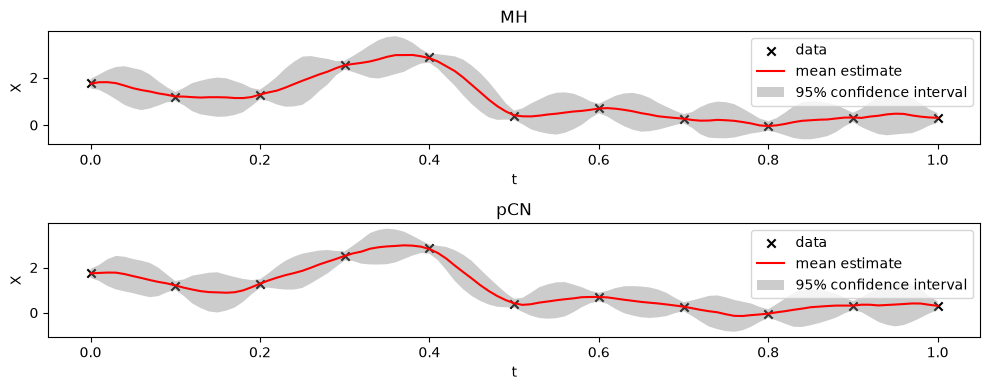

In [62]:
np.random.seed(0)

length_scale = 0.1
nu = 1.5
kernel = Matern(length_scale=length_scale, nu=nu)

t, X, ts, chain_mh, probs_mh, chain_pcn, probs_pcn = random_test_1d_mcmc(11, 101, kernel, 100_000, 0.1, 0.1)

tail_mh = chain_mh[-50000:]
tail_pcn = chain_pcn[-50000:]

mu_mh = tail_mh.mean(0)
std_mh = tail_mh.std(0)

mu_pcn = tail_pcn.mean(0)
std_pcn = tail_pcn.std(0)

_, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4))
ax1.scatter(t, X, c='k', marker="x", label="data")
ax1.plot(ts, mu_mh, 'r', label="mean estimate")
ax1.fill_between(ts, mu_mh + 2*std_mh, mu_mh - 2*std_mh,
                 color="gray", alpha=0.4, edgecolor=None,
                 label="95% confidence interval")
ax1.set_title("MH")
ax1.set_xlabel("t")
ax1.set_ylabel("X")
ax1.legend()
            

ax2.scatter(t, X, c='k', marker="x", label="data")
ax2.plot(ts, mu_pcn, 'r', label="mean estimate")
ax2.fill_between(ts, mu_pcn + 2*std_pcn, mu_pcn - 2*std_pcn,
                 color="gray", alpha=0.4, edgecolor=None,
                 label="95% confidence interval")
ax2.set_title("pCN")
ax2.set_xlabel("t")
ax2.set_ylabel("X")
ax2.legend()

plt.tight_layout()
plt.savefig("mcmc_1d.pdf")

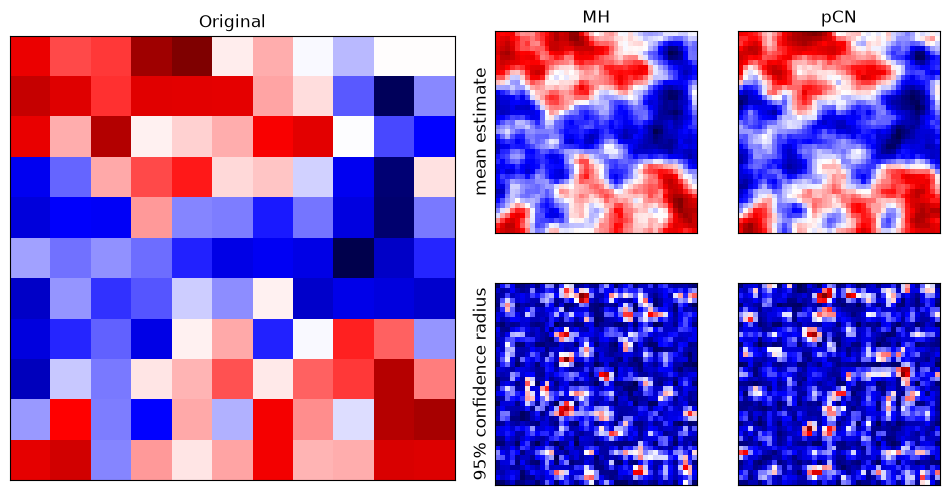

In [63]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4)

np.random.seed(0)

# One large subplot spanning the first 2x2 block
ax_big = fig.add_subplot(gs[:, :2])
ax_big.set_xticks([], [])
ax_big.set_yticks([], [])
ax_big.set_title("Original")

# Four normal subplots
ax1 = fig.add_subplot(gs[0, 2])
ax2 = fig.add_subplot(gs[0, 3])
ax3 = fig.add_subplot(gs[1, 2])
ax4 = fig.add_subplot(gs[1, 3])
for ax in (ax1, ax2, ax3, ax4):
    ax.set_xticks([], [])
    ax.set_yticks([], [])
ax1.set_title("MH")
ax2.set_title("pCN")
ax1.set_ylabel("mean estimate", fontsize=12)
ax3.set_ylabel("95% confidence radius", fontsize=12)

n = 11
ns = 41
len_chain = 40_000
sigma = 0.1
beta = 1e-2

length_scale = 0.1
nu = 1.5
kernel = Matern(length_scale=length_scale, nu=nu)

t, X, ts, chain_mh, probs_mh, chain_pcn, probs_pcn = random_test_2d_mcmc(n, ns, kernel, len_chain, sigma, beta)

levels = np.linspace(-3, 3, 255)

imshow = ax_big.imshow(X.reshape((n, n)), cmap="seismic")

for chain, (x1, x2) in zip((chain_mh, chain_pcn), ((ax1, ax3), (ax2, ax4))):
    tail = chain[-len_chain//2:]
    mu = tail.mean(0)
    std = tail.std(0)
    x1.imshow(mu.reshape((ns, ns)), cmap="seismic")
    x2.imshow(2 * std.reshape((ns, ns)), cmap="seismic")

plt.savefig("mcmc_2d.pdf")

### Benchmark and visualize

In [3]:
np.random.seed(0)

N = [21, 41, 81, 161, 321]
Ns = [41, 81, 161, 321, 641]
B = 10**np.linspace(-3, -1, 9)

chain_length = 20_000
sigma = 0.1

length_scale = 0.1
nu = 1.5
kernel = Matern(length_scale=length_scale, nu=nu)

def mcmc_1d_wrap(n, ns, b):
    _, _, _, _, probs_mh, _, probs_pcn = random_test_1d_mcmc(n, ns, kernel, chain_length, sigma, b)
    return probs_mh.mean(), probs_pcn.mean()

data_n = Parallel(2)(delayed(mcmc_1d_wrap)(n, ns, s) for n, ns, s in product(N, [Ns[-1]], B))
data_ns = Parallel(2)(delayed(mcmc_1d_wrap)(n, ns, s) for n, ns, s in product([N[0]], Ns, B))

/var/folders/r7/lrp1vtg90zx0m34pgg8fr_bs0yg2r7/T/ipykernel_37378/953350517.py:23: RuntimeWarning: overflow encountered in exp
/var/folders/r7/lrp1vtg90zx0m34pgg8fr_bs0yg2r7/T/ipykernel_37378/953350517.py:53: RuntimeWarning: overflow encountered in exp


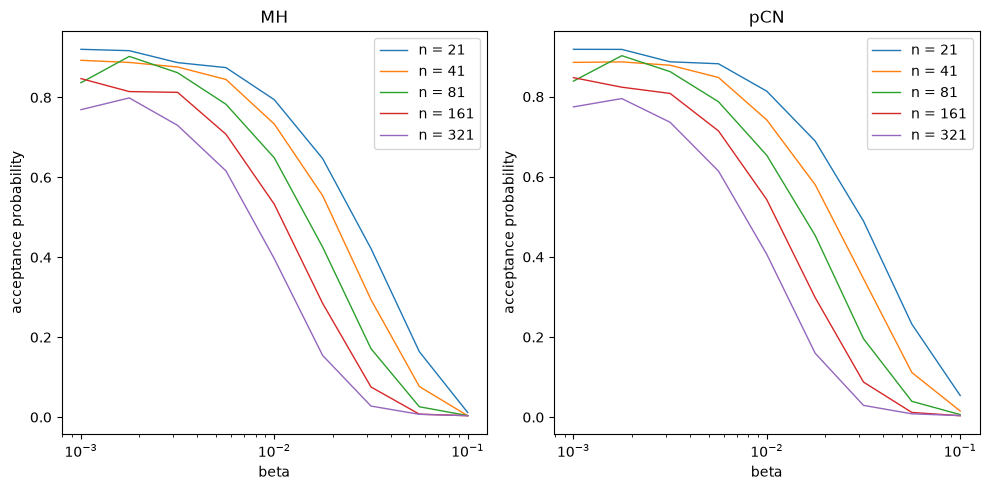

In [4]:
mh_n, pcn_n = np.asarray(data_n).T

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(B, mh_n.reshape((5, 9)).T, linewidth=1.0)
ax2.plot(B, pcn_n.reshape((5, 9)).T, linewidth=1.0)
ax1.legend([f"{n = }" for n in N])
ax2.legend([f"{n = }" for n in N])
ax1.set_title("MH")
ax2.set_title("pCN")

ax1.set_xscale("log")
ax2.set_xscale("log")

for ax in (ax1, ax2):
    ax.set_xlabel("beta")
    ax.set_ylabel("acceptance probability")

plt.tight_layout()
plt.savefig("1d_n.pdf")

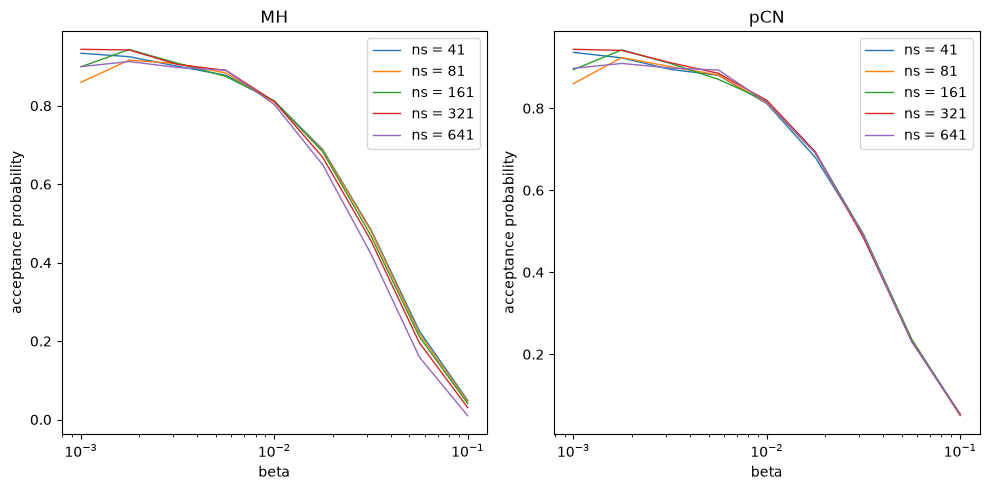

In [5]:
mh_ns, pcn_ns = np.asarray(data_ns).T

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(B, mh_ns.reshape((5, 9)).T, linewidth=1.0)
ax2.plot(B, pcn_ns.reshape((5, 9)).T, linewidth=1.0)
ax1.legend([f"{ns = }" for ns in Ns])
ax2.legend([f"{ns = }" for ns in Ns])
ax1.set_title("MH")
ax2.set_title("pCN")

ax1.set_xscale("log")
ax2.set_xscale("log")

for ax in (ax1, ax2):
    ax.set_xlabel("beta")
    ax.set_ylabel("acceptance probability")

plt.tight_layout()
plt.savefig("1d_ns.pdf")

In [6]:
np.random.seed(0)

N = [3, 6, 11, 21]
Ns = [6, 11, 21, 41]
B = 10**np.linspace(-3, -1, 9)

chain_length = 20_000
sigma = 0.1

length_scale = 0.1
nu = 1.5
kernel = Matern(length_scale=length_scale, nu=nu)

def mcmc_2d_wrap(n, ns, b):
    _, _, _, _, probs_mh, _, probs_pcn = random_test_2d_mcmc(n, ns, kernel, chain_length, sigma, b)
    return probs_mh.mean(), probs_pcn.mean()

data_n = Parallel(4)(delayed(mcmc_2d_wrap)(n, ns, s) for n, ns, s in product(N, [Ns[-1]], B))
data_ns = Parallel(4)(delayed(mcmc_2d_wrap)(n, ns, s) for n, ns, s in product([N[0]], Ns, B))

/Users/z068427/Git/bcpe/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/r7/lrp1vtg90zx0m34pgg8fr_bs0yg2r7/T/ipykernel_37378/953350517.py:23: RuntimeWarning: overflow encountered in exp
/var/folders/r7/lrp1vtg90zx0m34pgg8fr_bs0yg2r7/T/ipykernel_37378/953350517.py:23: RuntimeWarning: overflow encountered in exp
/var/folders/r7/lrp1vtg90zx0m34pgg8fr_bs0yg2r7/T/ipykernel_37378/953350517.py:53: RuntimeWarning: overflow encountered in exp


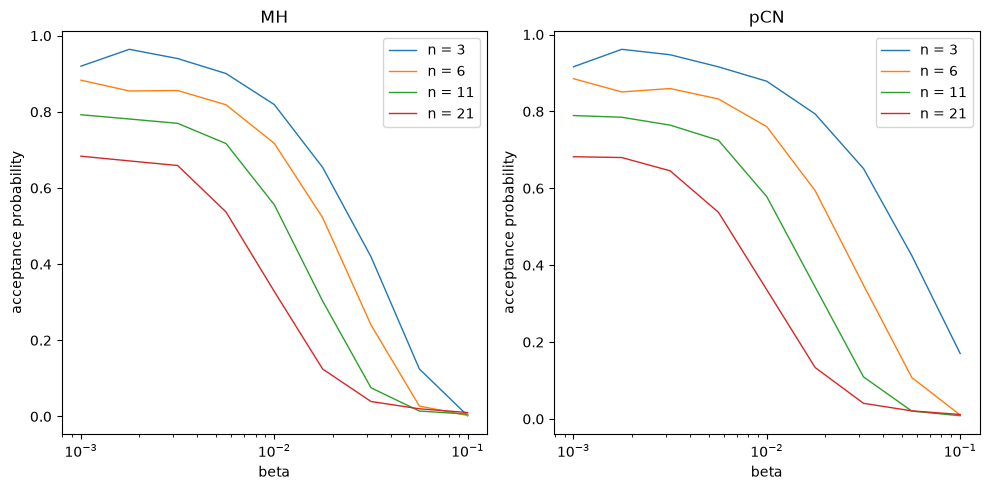

In [7]:
mh_n, pcn_n = np.asarray(data_n).T

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(B, mh_n.reshape((4, 9)).T, linewidth=1.0)
ax2.plot(B, pcn_n.reshape((4, 9)).T, linewidth=1.0)
ax1.legend([f"{n = }" for n in N])
ax2.legend([f"{n = }" for n in N])
ax1.set_title("MH")
ax2.set_title("pCN")

ax1.set_xscale("log")
ax2.set_xscale("log")

for ax in (ax1, ax2):
    ax.set_xlabel("beta")
    ax.set_ylabel("acceptance probability")

plt.tight_layout()
plt.savefig("2d_n.pdf")

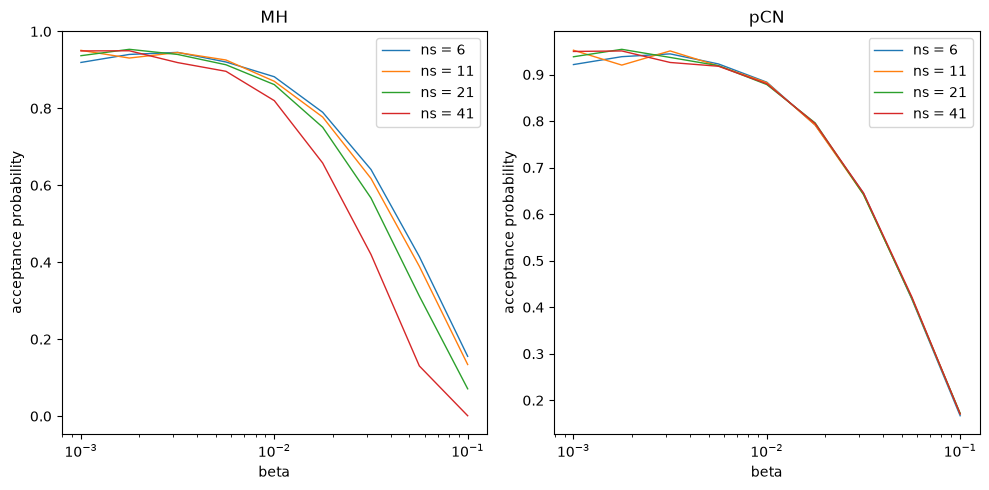

In [8]:
mh_ns, pcn_ns = np.asarray(data_ns).T

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(B, mh_ns.reshape((4, 9)).T, linewidth=1.0)
ax2.plot(B, pcn_ns.reshape((4, 9)).T, linewidth=1.0)
ax1.legend([f"{ns = }" for ns in Ns])
ax2.legend([f"{ns = }" for ns in Ns])
ax1.set_title("MH")
ax2.set_title("pCN")

ax1.set_xscale("log")
ax2.set_xscale("log")

for ax in (ax1, ax2):
    ax.set_xlabel("beta")
    ax.set_ylabel("acceptance probability")

plt.tight_layout()
plt.savefig("2d_ns.pdf")